## <strong> 11. 시계열 전용 연산

필요한 라이브러리: ```yfinance```, ```pandas_datareader```

In [1]:
!pip install yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 4.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 4.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.6/184.6 kB 2.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 2.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.6/215.6 kB 2.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 4.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 kB 3.4 MB/s eta 0:00:00
  Attempting uninstall: cffi
    Found existing installation: cffi 1.16.0
    Uninstalling cffi-1.16.0:
      Successfully uninstalled cffi-1.16.0
  Attempting uninstall: certifi
    Found existing installation: certifi 2023.7.22
 

In [2]:
import yfinance as yf
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
# 구글 주식 데이터 로딩
goog = yf.download("GOOG", start="2004-01-01", end="2026-04-27")
goog.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2004-08-19,2.478782,2.570680,2.370579,2.470382,897427216
2004-08-20,2.675672,2.694694,2.482735,2.495334,458857488
2004-08-23,2.702599,2.803390,2.693953,2.735949,366857939
2004-08-24,2.590690,2.756947,2.558575,2.748054,306396159
2004-08-25,2.618606,2.668014,2.566233,2.592914,184645512


In [4]:
# [+] 종가(Close) 데이터만 사용하기
goog = goog['Close']
goog

Ticker,GOOG
Date,
2004-08-19,2.478782
2004-08-20,2.675672
2004-08-23,2.702599
2004-08-24,2.590690
2004-08-25,2.618606
...,...
2026-04-20,335.399994
2026-04-21,330.470001
2026-04-22,337.730011


<Axes: xlabel='Date'>

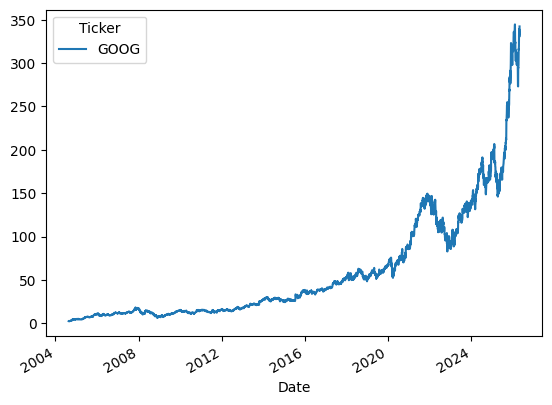

In [5]:
# [+] Lineplot 시각화
goog.plot()

#### <strong> 리샘플링(Resampling)
+ ```resample()```: 빈도를 기준으로 집계 연산
+ ```asfreq()```: 빈도 단위 별 데이터 선택

In [7]:
# [+] 다운샘플링: resample()
goog_downsampled = goog.resample('ME').mean()
goog_downsampled

Ticker,GOOG
Date,
2004-08-31,2.600380
2004-09-30,2.797144
2004-10-31,3.785391
2004-11-30,4.384812
2004-12-31,4.490414
...,...
2025-12-31,313.255306
2026-01-31,329.048692
2026-02-28,316.753696


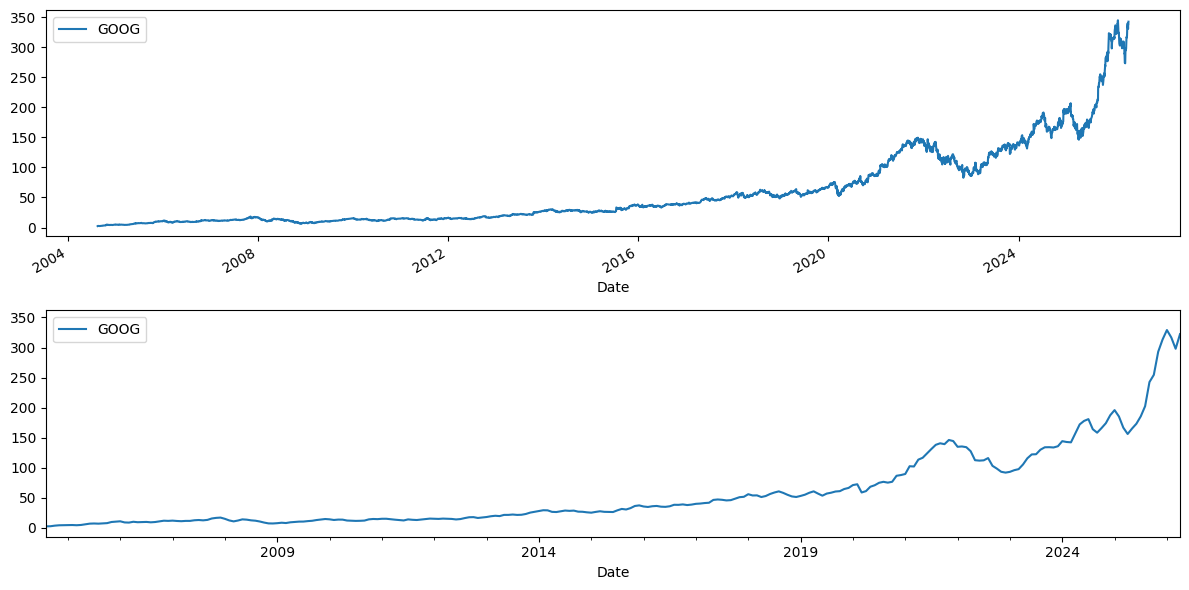

In [8]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))
goog.plot(label='original', ax=ax[0])
ax[0].legend()
goog_downsampled.plot(label='downsampled', ax=ax[1])
ax[1].legend()
plt.tight_layout()

Ticker            GOOG
Date                  
2004-08-31    2.528930
2004-09-30    3.201616
2004-10-31         NaN
2004-11-30    4.495603
2004-12-31    4.762651
...                ...
2025-11-30         NaN
2025-12-31  313.579071
2026-01-31         NaN
2026-02-28         NaN
2026-03-31  286.859985

[260 rows x 1 columns]


<Axes: xlabel='Date'>

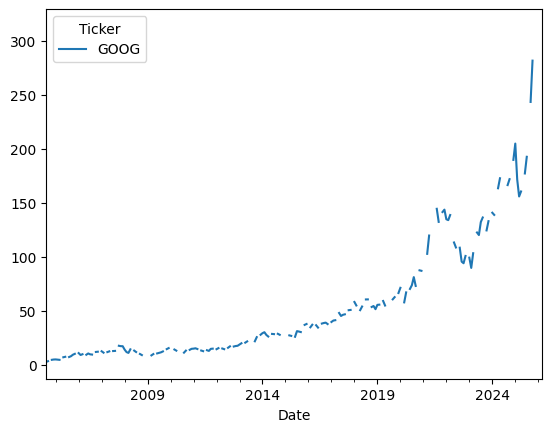

In [10]:
# [+] 다운샘플링: asfreq()
goog_downsampled = goog.asfreq('ME')
print(goog_downsampled)

goog_downsampled.plot()

In [11]:
# [+] 업샘플링: resample()
goog_upsampled = goog.resample('12h').median()
print(goog_upsampled)

Ticker                     GOOG
Date                           
2004-08-19 00:00:00    2.478782
2004-08-19 12:00:00         NaN
2004-08-20 00:00:00    2.675672
2004-08-20 12:00:00         NaN
2004-08-21 00:00:00         NaN
...                         ...
2026-04-22 00:00:00  337.730011
2026-04-22 12:00:00         NaN
2026-04-23 00:00:00  337.750000
2026-04-23 12:00:00         NaN
2026-04-24 00:00:00  342.320007

[15837 rows x 1 columns]


#### <strong> 시프팅(Shifting)
+ ```shift(periods)``` : ```periods``` 값 만큼 시계열 이동

In [12]:
# [+] 900일 뒤로 시프팅 적용
goog_shifted = goog.shift(periods=900)
goog_shifted

Ticker,GOOG
Date,
2004-08-19,NaN
2004-08-20,NaN
2004-08-23,NaN
2004-08-24,NaN
2004-08-25,NaN
...,...
2026-04-20,103.053940
2026-04-21,102.786140
2026-04-22,103.004333


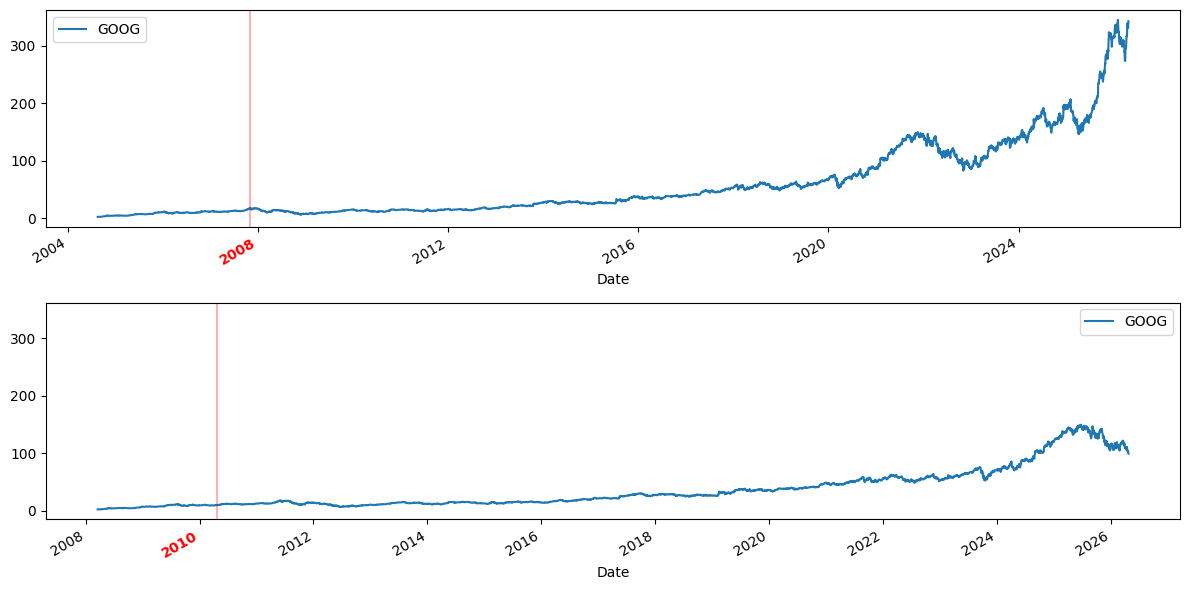

In [13]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))

# Legends and annotations
local_max = pd.to_datetime('2007-11-05')
offset = pd.Timedelta(900, 'D')

goog.plot(label='original', ax=ax[0])
ax[0].legend()
ax[0].get_xticklabels()[2].set(weight='heavy', color='red')
ax[0].axvline(local_max, alpha=0.3, color='red')

goog_shifted.plot(label='shifted 900 days', ax=ax[1])
ax[1].legend()
ax[1].get_xticklabels()[2].set(weight='heavy', color='red')
ax[1].axvline(local_max + offset, alpha=0.3, color='red')

plt.tight_layout()

In [14]:
# shifting 응용: 주가 변화율 계산
goog_shifted = goog.shift(periods=1) # [+] 시프팅
(goog - goog_shifted) / goog_shifted # [+] 주가 변화율 계산

Ticker,GOOG
Date,
2004-08-19,NaN
2004-08-20,0.079430
2004-08-23,0.010064
2004-08-24,-0.041408
2004-08-25,0.010775
...,...
2026-04-20,-0.011786
2026-04-21,-0.014699
2026-04-22,0.021969


Ticker          GOOG
Date                
2004-08-19       NaN
2004-08-20  0.196890
2004-08-23  0.026927
2004-08-24 -0.111908
2004-08-25  0.027915
...              ...
2026-04-20 -4.000000
2026-04-21 -4.929993
2026-04-22  7.260010
2026-04-23  0.019989
2026-04-24  4.570007

[5455 rows x 1 columns]


<Axes: xlabel='Date'>

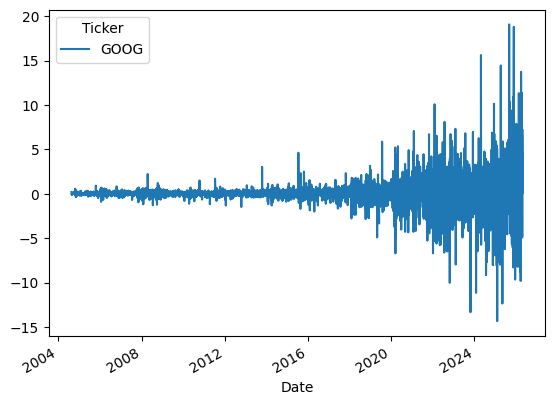

In [15]:
# shifting 응용: 차분 시계열 구하기
goog_diff = goog - goog_shifted  # [+] 차분
print(goog_diff)

goog_diff.plot()

#### <strong> 윈도잉(Windowing)

In [ ]:
# [+] 365일 단위 윈도잉
goog_rolled = ...
print(goog_rolled)

goog_rolled.mean().plot()

In [ ]:
data = pd.DataFrame({'input': goog.values.flatten(),
                     # moving average
                     'one-year rolling_mean': goog_rolled.mean().values.flatten(), 
                     # standard deviation
                     'one-year rolling_std': goog_rolled.std().values.flatten()}, index=goog.index)
ax = data.plot(style=['-', '--', ':'])
ax.lines[0].set_alpha(0.3)